## Poner los paquetes usados aqui

In [14]:
%%writefile requirements.txt

pandas
numpy
matplotlib
seaborn
plotly
nbformat

Overwriting requirements.txt


In [1]:
# Install a pip package in the current Jupyter kernel
import sys
!{sys.executable} -m pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable


In [9]:
# Importamos las librerias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import seaborn as sns

from IPython.display import display

### Vamos a visualizar los datos!!

In [4]:
data = pd.read_csv("data/healthcare_tp.csv")

display(data.head())
display(data.tail())


,Age,Gender,Blood Type,Medical Condition,Date of Admission,Discharge Date,Admission Type,Billing Amount,Medication,Test Results,Insurance Provider,Insurance Plan
0,56,Female,A+,Hypertension,2023-07-13,2023-07-16,Emergency,5374.88,Aspirin,Abnormal,Aetna,Gold
1,38,Male,A+,Obesity,2024-01-25,2024-02-06,Elective,1986.98,Orlistat,Abnormal,Cigna,Gold
2,56,Male,A+,Asthma,2024-07-30,2024-08-02,Emergency,6086.36,Inhaler,Abnormal,Blue Cross,Gold
3,42,Female,A+,Diabetes,2023-03-29,2023-04-06,Emergency,3589.38,Metformin,Abnormal,Aetna,Gold
4,54,Male,O+,Diabetes,2023-11-03,2023-11-13,Elective,2600.54,Insulin,Inconclusive,Aetna,Basic


,Age,Gender,Blood Type,Medical Condition,Date of Admission,Discharge Date,Admission Type,Billing Amount,Medication,Test Results,Insurance Provider,Insurance Plan
5995,44,Female,A+,Healthy,2024-08-21,2024-08-31,Emergency,3788.63,NaN,Normal,Medicare,Gold
5996,55,Male,O-,Obesity,2023-06-22,2023-06-29,Elective,2831.81,Orlistat,Normal,Cigna,Silver
5997,64,Female,A+,Diabetes,2024-01-07,2024-01-14,Elective,2588.33,Metformin,Inconclusive,Blue Cross,Platinum
5998,13,Female,O+,Obesity,2023-11-09,2023-11-20,Elective,1523.96,Orlistat,Abnormal,Cigna,Silver
5999,75,Male,B+,Hypertension,2023-08-10,2023-08-19,Elective,3736.62,Aspirin,Abnormal,Medicare,Gold


### Proporcion Hombres vs Mujeres

In [5]:
# hay que normalizar los datos antes de hacer la estadistica
data["Gender"] = data["Gender"].str.strip().str.lower()

# Conteo de hombres y mujeres
conteo_genero = (
    data["Gender"]
    .value_counts()
    .reset_index()
)
conteo_genero.columns = ["Gender", "Cantidad"]

# Pie chart interactivo
fig = px.pie(
    conteo_genero,
    names="Gender",
    values="Cantidad",
    title="Distribución por género",
    hole=0.4  # opcional: dona
)

fig.update_traces(textposition="inside", textinfo="percent+label")
fig.show()


### Edad por genero

Me parece medio raro los pibitos de entre 0 a 1 año

In [6]:
# Quiero ver la edad promedio y luego la edad de cada genero

fig = px.histogram(data, x="Age", color="Gender")
fig.show()

display(data[data["Age"] == 0])


,Age,Gender,Blood Type,Medical Condition,Date of Admission,Discharge Date,Admission Type,Billing Amount,Medication,Test Results,Insurance Provider,Insurance Plan
113,0,male,B+,Healthy,2024-08-10,2024-08-23,Elective,1187.43,NaN,Normal,Cigna,Platinum
369,0,female,AB-,Obesity,2023-10-24,2023-11-06,Elective,1908.80,Orlistat,Inconclusive,Blue Cross,Gold
378,0,male,AB-,Obesity,2023-08-23,2023-08-31,Emergency,2246.41,Paracetamol,Inconclusive,Blue Cross,Gold
585,0,male,AB-,Hypertension,2023-09-18,2023-09-23,Emergency,2443.35,Aspirin,Abnormal,Blue Cross,Gold
674,0,female,O+,Healthy,2023-06-04,2023-06-12,Emergency,3147.61,NaN,Abnormal,Cigna,Gold
743,0,male,A+,Hypertension,2023-02-18,2023-02-27,Elective,1398.92,Beta Blocker,Abnormal,Blue Cross,Silver
991,0,male,AB-,Hypertension,2024-06-13,2024-06-23,Emergency,2507.04,Aspirin,Abnormal,Blue Cross,Silver
1460,0,male,O+,Healthy,2024-11-18,2024-11-25,Elective,1687.24,NaN,Normal,Blue Cross,Platinum
1701,0,male,A+,Hypertension,2023-02-11,2023-02-21,Elective,1233.38,Aspirin,Inconclusive,Blue Cross,Basic
1800,0,female,B-,Obesity,2023-02-28,2023-03-03,Emergency,3348.29,Paracetamol,Normal,Medicare,Silver


Chequeamos tema anomalías en edad

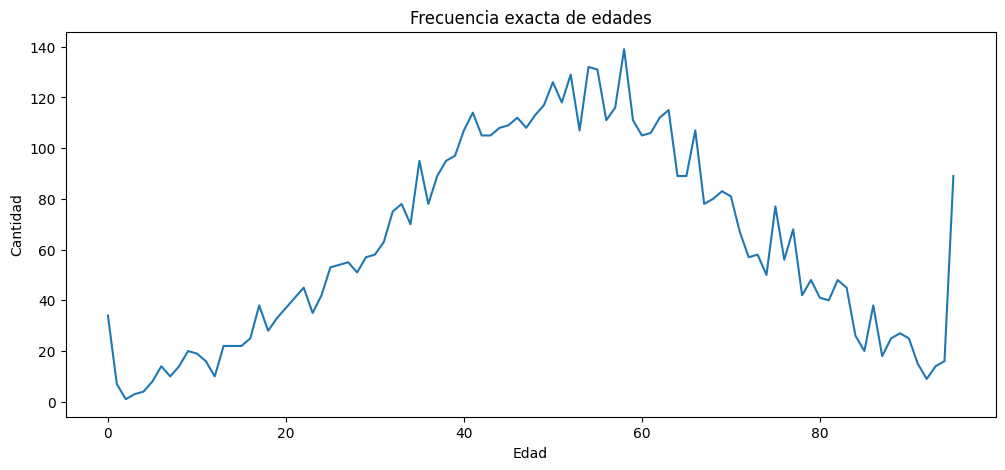

Age
58    139
54    132
55    131
52    129
50    126
51    118
49    117
57    116
63    115
41    114
Name: count, dtype: int64


In [10]:
# Frecuencia exacta de edades
age_counts = data['Age'].value_counts().sort_index()

plt.figure(figsize=(12,5))
sns.lineplot(x=age_counts.index, y=age_counts.values)
plt.title("Frecuencia exacta de edades")
plt.xlabel("Edad")
plt.ylabel("Cantidad")
plt.show()

# Top edades más frecuentes
print(age_counts.sort_values(ascending=False).head(10))

### Pirámide poblacional

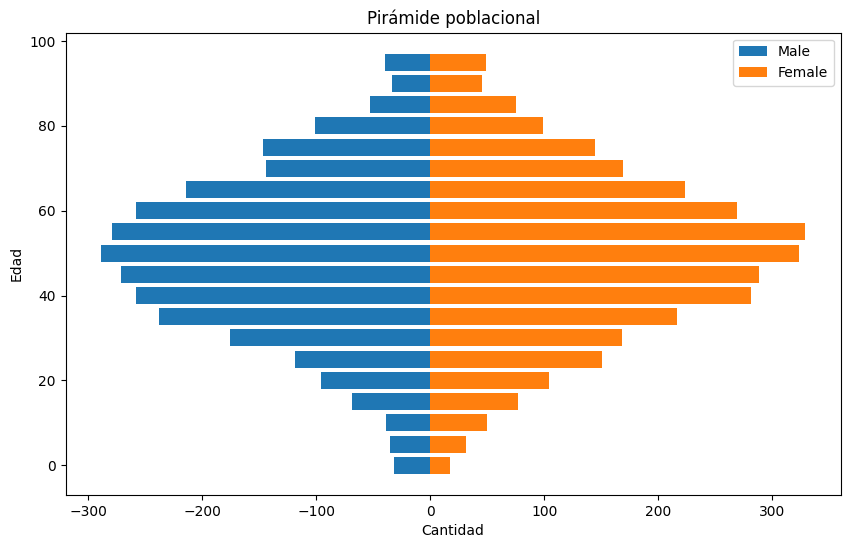

In [11]:
male = data[data['Gender'] == 'male']['Age']
female = data[data['Gender'] == 'female']['Age']

bins = np.arange(0, 101, 5)

male_counts = np.histogram(male, bins=bins)[0]
female_counts = np.histogram(female, bins=bins)[0]

plt.figure(figsize=(10,6))
plt.barh(bins[:-1], -male_counts, height=4, label='Male')
plt.barh(bins[:-1], female_counts, height=4, label='Female')

plt.title("Pirámide poblacional")
plt.xlabel("Cantidad")
plt.ylabel("Edad")
plt.legend()
plt.show()

### Drivers del gasto

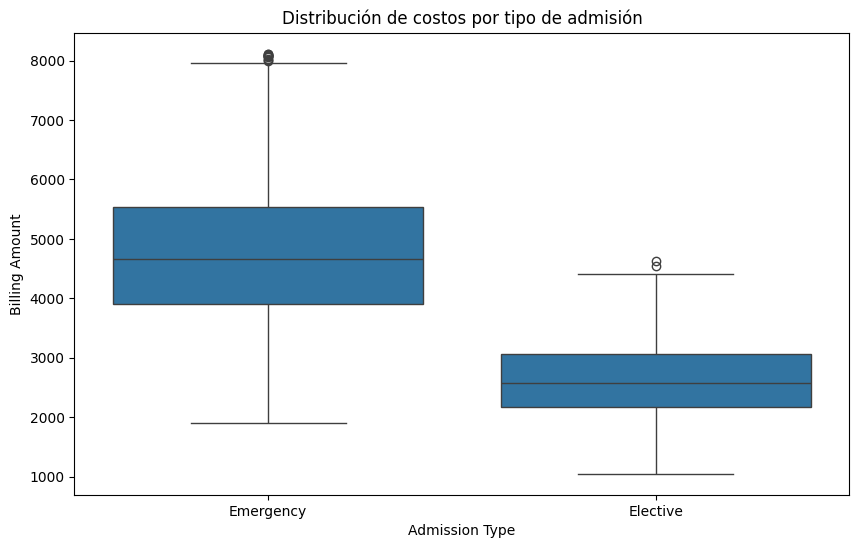

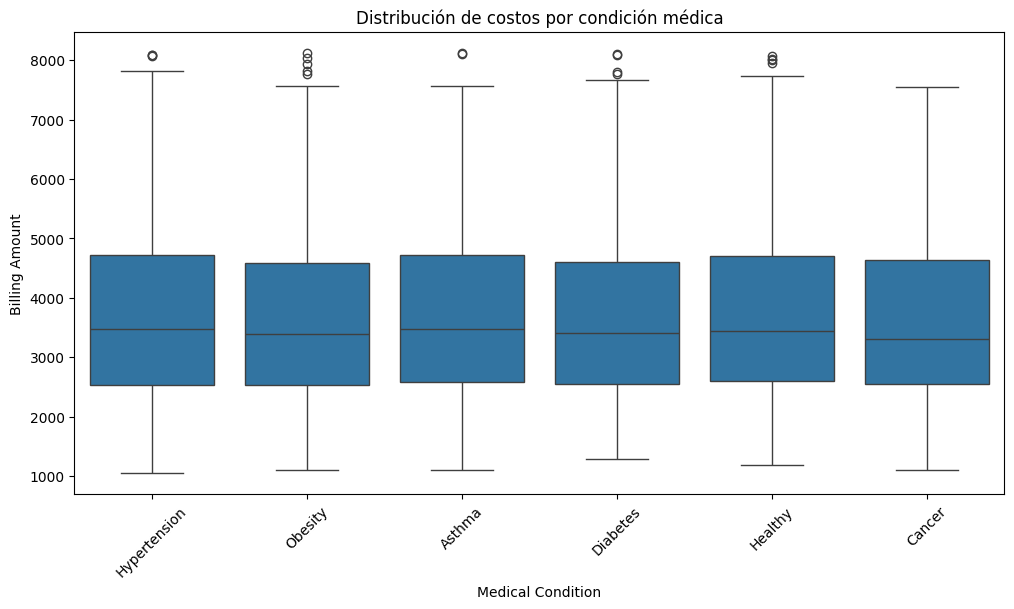

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data, x='Admission Type', y='Billing Amount')
plt.title("Distribución de costos por tipo de admisión")
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=data, x='Medical Condition', y='Billing Amount')
plt.xticks(rotation=45)
plt.title("Distribución de costos por condición médica")
plt.show()

### Correlación entre variables numéricas

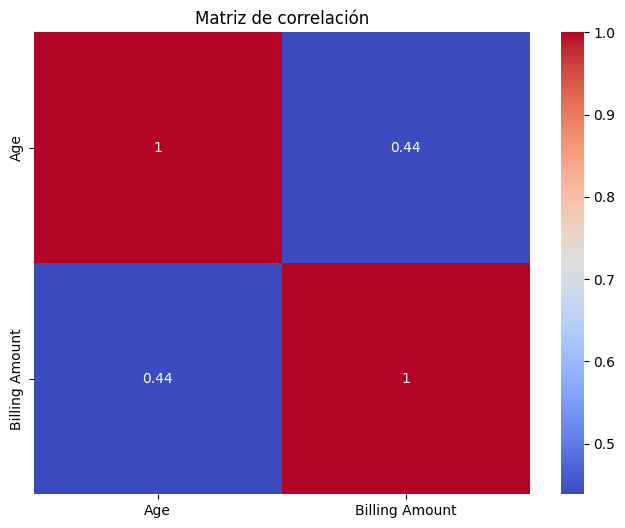

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

### Edad vs duración (eficiencia operativa)

C:\Users\AGUS\AppData\Local\Temp\ipykernel_9868\3815973804.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  data['Date of Admission'] = pd.to_datetime(data['Date of Admission'], dayfirst=True)
C:\Users\AGUS\AppData\Local\Temp\ipykernel_9868\3815973804.py:3: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  data['Discharge Date'] = pd.to_datetime(data['Discharge Date'], dayfirst=True)


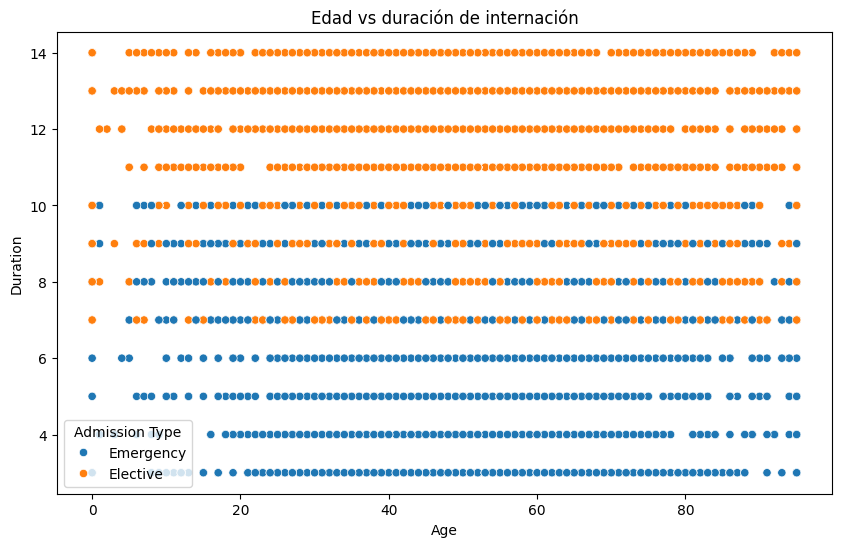

In [16]:
# Convertimos las columnas al formato datetime de pandas
data['Date of Admission'] = pd.to_datetime(data['Date of Admission'], dayfirst=True)
data['Discharge Date'] = pd.to_datetime(data['Discharge Date'], dayfirst=True)
# Creamos la columna restando: Alta menos Admisión
data['Duration'] = (data['Discharge Date'] - data['Date of Admission']).dt.days

plt.figure(figsize=(10,6))
sns.scatterplot(data=data, x='Age', y='Duration', hue='Admission Type')
plt.title("Edad vs duración de internación")
plt.show()

### Edad vs. Costo

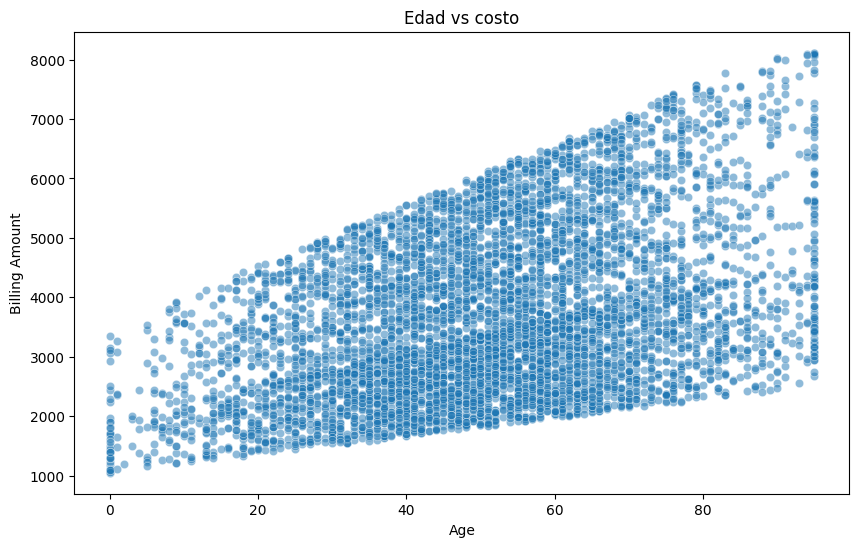

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=data, x='Age', y='Billing Amount', alpha=0.5)
plt.title("Edad vs costo")
plt.show()

### Pertinencia Médica

La idea es responder "¿Los medicamentos se adaptan a la condición?"

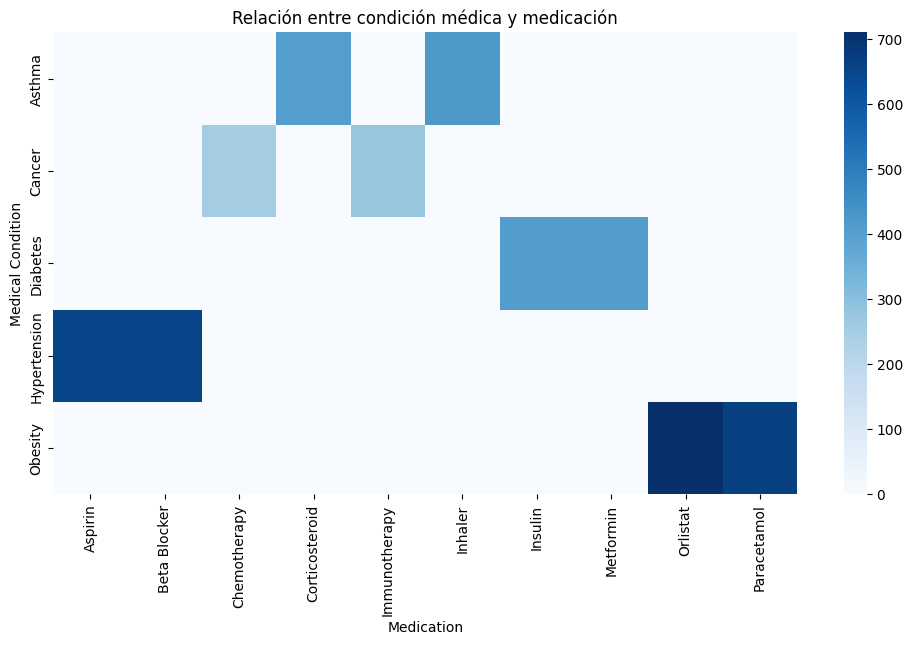

In [19]:
# Tabla cruzada
med_condition_medication = pd.crosstab(data['Medical Condition'], data['Medication'])

plt.figure(figsize=(12,6))
sns.heatmap(med_condition_medication, cmap='Blues')
plt.title("Relación entre condición médica y medicación")
plt.show()

### Resultados de tests (prevención vs reacción)

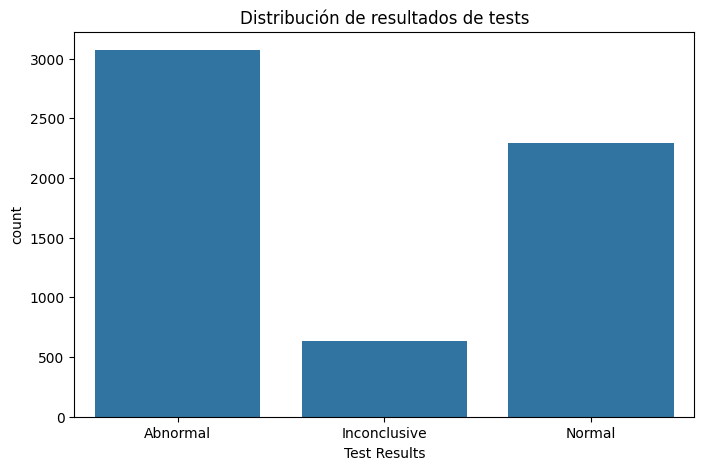

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(data=data, x='Test Results')
plt.title("Distribución de resultados de tests")
plt.show()

Muchos "Abnormal" → sistema reactivo, no preventivo

### Duración vs costo (eficiencia hospitalaria)

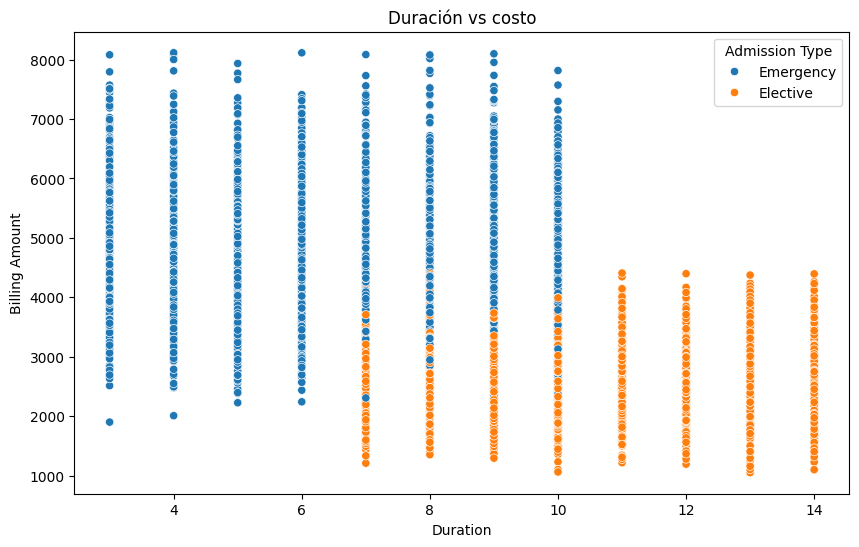

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=data, x='Duration', y='Billing Amount', hue='Admission Type')
plt.title("Duración vs costo")
plt.show()